# Semester 4 Coding Portfolio Part 2: Regression for Count Data

This notebook covers the following topics:
 - Cleaning count data
 - Linear regression of count data
 - Log-linear regression
 - Poisson regression

This notebook is expected to take around 20 hours to complete:
 - 4 hours for the formative part
 - 6 hours of self-study on the topics covered by this notebook
 - 10 hours for the summative part of this notebook

Like all notebooks in this portfolio, it is split into two sections:
 - Formative 
 - Summative

<b>Formative section</b><br>
Simply complete the given functions! You may ask for help from fellow students and TAs on this section, and solutions might be provided later on.

<b>Summative section</b><br>
In this section, you are asked to do original work with little guidance, based on the skills you learned in the formative part (as well as lectures and workshops).
This section is graded not just on passing automated tests, but also on quality, originality, and effort (see assessment criteria in the assignment description).

In [1]:
# TODO: Please enter your student number here
STUDENT_NUMBER = 0

# Formative Section
Please do not add additional cells to this section, and do not delete given code. Simply fill out the code or answer questions in the given cells.

### Part 1: Load and clean data
In this workbook we are going to build a model to predict the expected number of individuals killed from a terrorist attack. The occasion in which this would be used would be the moment a terrorism event would happen, a relevant intelligenece organisation might be tasked to generate an estimate for the expected severity of the event. 

When you replicate this workbook with your own data, I'd like to see evidence of you iterating over what model to use, which covariates to include and whether any interactions of non-linearities (e.g. including a squared term) should be included. Here we will use a very simple model which will not fit the data extremely well, but focus on interpretation of coefficients and choosing the correct `data generating process` (i.e. the correct likelihood function and / or transformation to apply to the data before fitting). 

In [2]:
# Import Necessary Libraries
import os
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import multivariate_normal, bernoulli, beta, norm
from scipy.stats import ks_2samp
from scipy.special import expit as logistic_sigmoid
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.metrics import brier_score_loss
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.metrics import balanced_accuracy_score, brier_score_loss, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.model_selection import KFold
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

# Set display option to avoid scientific notation in pandas, show up to 5 decimal points
pd.set_option('display.float_format', lambda x: '%.5f' % x)
# and numpy
np.set_printoptions(suppress=True, precision=5)

In [3]:
# Load the clean terrorism dataset (same dataset as for notebook 1)
df = pd.read_csv('sem4_portfolio_1_data.csv', low_memory=False)

Explore the distribution of `nkill`, the number of people killed in a given terrorism incident. Specifically, plot a histogram of of the variable.

In [4]:
# TODO 1: Look at the first 1000 cases to get a tangible idea of what we are working with

first_1000_cases = df['nkill'].dropna().astype(int).head(1000).to_list()

#. Your solution here ...

print(first_1000_cases)

[1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 7, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 47, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 36, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0

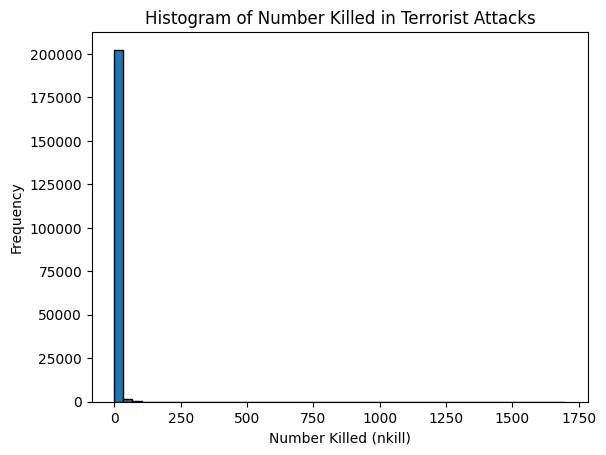

In [5]:
# TODO 2: Plot the histogram

#. Your solution here ...
plt.hist(df['nkill'], bins=50, edgecolor='black')
plt.xlabel('Number Killed (nkill)')
plt.ylabel('Frequency')
plt.title('Histogram of Number Killed in Terrorist Attacks')
plt.show()

What can you say about the distribution?

#!# BEGIN ANSWER
The distribution of number of individuals killed in terrorism incidents is clearly skewed and peaked on 0, as most terrorist attacks do not cause any deaths. The distribution is non-Gaussian.
#!# END ANSWER

Take the log of nkill. Apply any necessary transformation to the data for this to work.

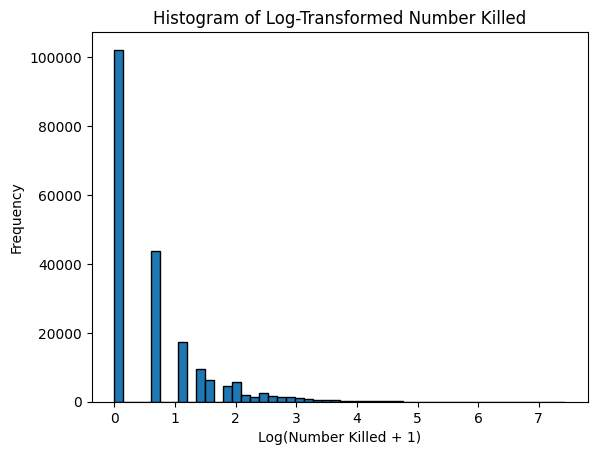

In [6]:
# TODO 3: Plot the histogram of the log of nkill

#. Your solution here ...
df['log_nkill'] = np.log(df['nkill'] + 1)
plt.hist(df['log_nkill'], bins=50, edgecolor='black')
plt.xlabel('Log(Number Killed + 1)')
plt.ylabel('Frequency')
plt.title('Histogram of Log-Transformed Number Killed')
plt.show()

What can you say about the resulting distribution? 

#!# BEGIN ANSWER
The distribution is still skewed and non-normal, however it is less peaked and exhibits a more half-normal character. It is still a clearly non-Gaussian distribution. 
#!# END ANSWER

### Part 2: Linear Regression

A naive approach to modeling this data may still be to use linear regression, and hence assume a normal distribution around the dependent variable. Note that, implicitly, assuming a normal around the dependent variable actually entails that your `residuals` -- so what is left of the variability in your dependent variable after netting the `systematic` component -- should be normally distributed:

$Y_i \sim N(mu_i, \sigma^2) \rightarrow (Y_i - mu_i) \sim N(0,\sigma^2)$

There are formal tests to see if your model's assumptions (here i. conditional independnce of each observation; ii. constant variance (homoskedasticity); iii. normality of errors; iv. linearity in parameters). The branch of statistics you are being taught does not obsess over these assumptions, and simply asks: `which model fits the data best ?`. So instead of testing assumptions we just fit different models and compare the `generalisation error`. In what follows for simplicity we compare models with in-sample performance, but this comparison of error metrics would be more effective / legitimate if applied to out-of-sample data. 

Select some variable which you should include in the model. Include `terrorist.org`.

In [7]:
# Let's create a cbrn variable (no nuclear in the sample (un?)fortunately )
df['weapon.type_cbrn'] = df['weapon.type_chemical'] +  df['weapon.type_biological'] +  df['weapon.type_radiological']  

# TODO 4: Assuming 'df' is your DataFrame containing the dataset "nkill"
# Selecti relevant variables including the target variable

#!# BEGIN SOLUTION
data = df[['nkill',
           'suicide', 
           'nperps', 
           'terrorist.org',
           'weapon.type_explosives', 
           'weapon.type_incendiary',
           'weapon.type_firearms',
           'weapon.type_cbrn',
           'weapon.type_melee',
           'weapon.type_sabotage.equipment',
           'weapon.type_vehicle..not.to.include.vehicle.borne.explosives..i.e...car.or.truck.bombs.',
           'weapon.type_fake.weapons',
           'attack.type_assassination',
           'attack.type_hostage.taking..kidnapping.',
           # 'attack.type_bombing.explosion',
           'attack.type_facility.infrastructure.attack',
           'attack.type_armed.assault',
           'attack.type_hijacking',
           # 'attack.type_unknown',
           'attack.type_unarmed.assault',
           'attack.type_hostage.taking..barricade.incident.',
           # 'target.type_private.citizens...property',
           'target.type_government..diplomatic.',
           'target.type_journalists...media',
           'target.type_police',
           'target.type_utilities',
           'target.type_military',
           'target.type_government..general.',
           'target.type_airports...aircraft',
           'target.type_business',
           'target.type_educational.institution',
           'target.type_violent.political.party',
           'target.type_religious.figures.institutions',
           # 'target.type_unknown',
           'target.type_transportation',
           'target.type_tourists',
           'target.type_ngo',
           'target.type_telecommunication',
           'target.type_food.or.water.supply',
           'target.type_terrorists.non.state.militia',
           'target.type_other',
           'target.type_maritime',
           'target.type_abortion.related'
          ]]
#!# END SOLUTION

Pick some terrorist organisations to include in the model. One option is to identify the 10 (?) most frequent, group all those outside this group into a new class `other`. Make sure you edit the `terrorist.org` variable to reflect this. 

In [8]:
!pip install kneed

Elbow point at: 27


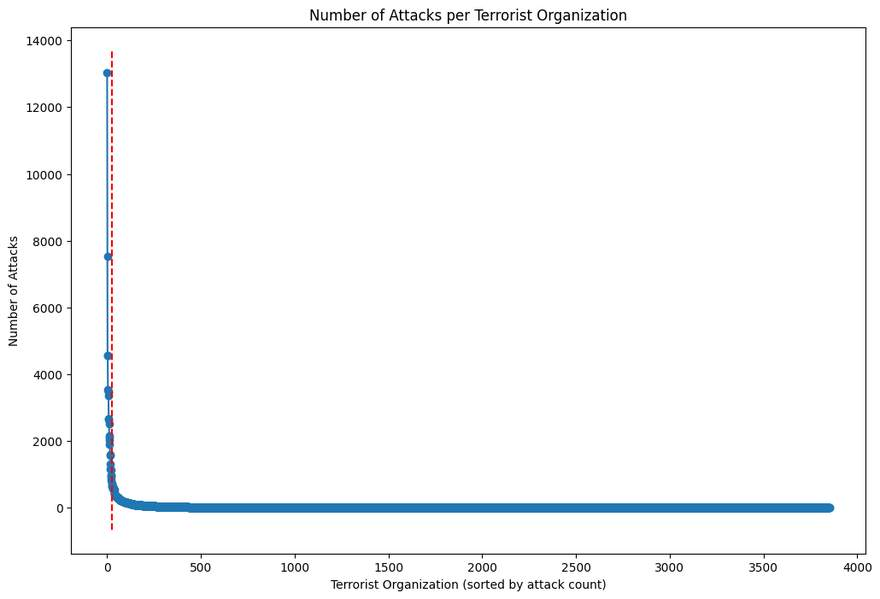

In [9]:
from kneed import KneeLocator

# TODO 5: Exclude unknown organizations
# Count the number of attacks per organization excluding 'Unknown'
# Prepare data for use with Kneedle algorithm
# Use KneeLocator to find the elbow point


#!# BEGIN SOLUTION
# To pick the optimal number of terrorist groups I'm going to use the elbow methods 
# Excluding 'Unknown'
df_filtered = df[df['terrorist.org'] != 'Unknown']

# Counting the number of attacks per organization
attacks_per_org = df_filtered['terrorist.org'].value_counts().sort_values(ascending=False)

# Converting to a format suitable for the Kneedle algorithm
# The Kneedle algorithm expects the data to be in a sorted order
x = range(1, len(attacks_per_org) + 1)
y = attacks_per_org.values

# Finding the elbow point
kneedle = KneeLocator(x, y, curve='convex', direction='decreasing')
elbow_point = kneedle.elbow
#!# END SOLUTION


print(f"Elbow point at: {elbow_point}")

# Plotting
plt.figure(figsize=(12, 8))
plt.plot(x, y, marker='o', linestyle='-')
plt.vlines(elbow_point, plt.ylim()[0], plt.ylim()[1], linestyles='dashed',color = 'red')
plt.xlabel('Terrorist Organization (sorted by attack count)')
plt.ylabel('Number of Attacks')
plt.title('Number of Attacks per Terrorist Organization')

plt.show()

In [10]:
# TODO 6: Identify the most common orgs (you should have some code before this that allows you to identify these by frequency or otherwise)

#!# BEGIN SOLUTION
most_common_orgs = attacks_per_org.index.to_list()[:elbow_point]
#!# END SOLUTION

# Modify the df['terrorist.org'] column
# Check if each value is in the most_common_orgs list, otherwise replace it with 'other'
df['terrorist.org'] = df['terrorist.org'].apply(lambda org: org if org in most_common_orgs else 'other')

Now create your design matrix and you dependent variable vector. Ensure you include terrorist.org, one-hot encode it and drop the first (most frequent) org (the Taliban). This will serve as your reference. Drop incomplete records. To ensure a successful model fit, drop columns that have 0 variance and those which exhibit multicollinearity. Standardise your covariates. 

In [11]:
# TODO 7: Select predictors and target variable before dropping missing values
X = ... # df[['nkill', ...]]

# Drop rows with missing values in any selected variable or the target
data_cleaned = ...

#!# BEGIN SOLUTION
X = df[[
    'nkill',
    'suicide', 
    'nperps',
    'terrorist.org',
    'weapon.type_explosives', 
    'weapon.type_incendiary',
    'weapon.type_firearms',
    'weapon.type_cbrn',
    'weapon.type_melee',
    'weapon.type_sabotage.equipment',
    'weapon.type_vehicle..not.to.include.vehicle.borne.explosives..i.e...car.or.truck.bombs.',
    'weapon.type_fake.weapons',
    'attack.type_assassination',
    'attack.type_hostage.taking..kidnapping.',
    # 'attack.type_bombing.explosion', 
    'attack.type_facility.infrastructure.attack',
    'attack.type_armed.assault',
    'attack.type_hijacking',
    # 'attack.type_unknown',
    'attack.type_unarmed.assault',
    'attack.type_hostage.taking..barricade.incident.',
    # 'target.type_private.citizens...property',
    'target.type_government..diplomatic.',
    'target.type_journalists...media',
    'target.type_police',
    'target.type_utilities',
    'target.type_military',
    'target.type_government..general.',
    'target.type_airports...aircraft',
    'target.type_business',
    'target.type_educational.institution',
    'target.type_violent.political.party',
    'target.type_religious.figures.institutions',
    # 'target.type_unknown',
    'target.type_transportation',
    'target.type_tourists',
    'target.type_ngo',
    'target.type_telecommunication',
    'target.type_food.or.water.supply',
    'target.type_terrorists.non.state.militia',
    'target.type_other',
    'target.type_maritime',
    'target.type_abortion.related']]

# Drop rows with missing values in any selected variable or the target
data_cleaned = X.dropna(axis=0, how='any')
#!# END SOLUTION

# Separate predictors and target variable after cleaning
y_cleaned = data_cleaned['nkill']
y_log_cleaned = np.log(data_cleaned['nkill']+1)
X_cleaned = data_cleaned.drop(columns=['nkill'])

In [12]:
# TODO 8: One-hot encoding categorical variables and dropping the first dummy to avoid multicollinearity
X_encoded = pd.get_dummies(...).astype(int)

#!# BEGIN SOLUTION
X_encoded = pd.get_dummies(X_cleaned, columns=['terrorist.org'], drop_first=True).astype(int)
#!# END SOLUTION

In [13]:
# Drop variables with 0 variability (no information) (I will do this for you because you haven't used this before)

# VarianceThreshold with a threshold of 0 (default) to remove 0 variance columns
selector = VarianceThreshold()
X_encoded_var_filtered = selector.fit_transform(X_encoded)
# Get the columns after variance thresholding
X_encoded_var_filtered = X_encoded.iloc[:, selector.get_support(indices=True)]

In [14]:
# Calculate the correlation matrix (absolute value - we don't care about direction of correlation)
corr_matrix = X_encoded_var_filtered.corr().abs()

# Select upper triangle of correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Initialize an empty list to keep track of columns to drop
to_drop = []

# Iterate over the columns of the upper triangle
for column in upper_tri.columns:
    for row in upper_tri.index:
        # Check if the correlation is above the threshold and the column hasn't been considered yet
        if upper_tri.loc[row, column] > 0.9 and column not in to_drop and row not in to_drop:
            to_drop.append(column)
            break  # Break the loop once a column is marked for dropping

# 'to_drop' contains columns where only one of each highly correlated pair is considered for dropping

In [15]:
# TODO 9: Drop highly correlated features 

#. Your solution here ...
X_encoded_final = X_encoded_var_filtered.drop(columns=to_drop)

In [16]:
# Standardise features to help with interpretation (Again I will do this for you because you haven't seen this before.)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit on training set only
scaler.fit(X_encoded_final)

# Apply transform to both the training set and the test set
X_train_scaled = pd.DataFrame(scaler.transform(X_encoded_final), columns=X_encoded_final.columns, index=X_encoded_final.index)

Fit a linear regression model to the data. Print the summary and a histogram of the residuals. Is it normally distributed ? 

In [17]:
# TODO 10: Adding a constant for the intercept

#. Your solution here ...
X_encoded_with_const = sm.add_constant(X_train_scaled)

In [18]:
from IPython.core.display import display, HTML
# This should help you visualise all your coefficients if you have many
display(HTML("<style>.container { width:90% !important; }</style>"))

# TODO 11: Fitting the linear regression model


#. Your solution here ...
model = sm.OLS(y_cleaned, X_encoded_with_const).fit()

# Displaying the regression results
print(model.summary())

/var/folders/rf/c4wm9pq50j3bjhbyfct63d2h0000gn/T/ipykernel_55113/1296665617.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


                            OLS Regression Results                            
Dep. Variable:                  nkill   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     33.21
Date:                Sun, 23 Mar 2025   Prob (F-statistic):               0.00
Time:                        17:57:17   Log-Likelihood:            -1.3656e+05
No. Observations:               32775   AIC:                         2.732e+05
Df Residuals:                   32710   BIC:                         2.738e+05
Df Model:                          64                                         
Covariance Type:            nonrobust                                         
                                                                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

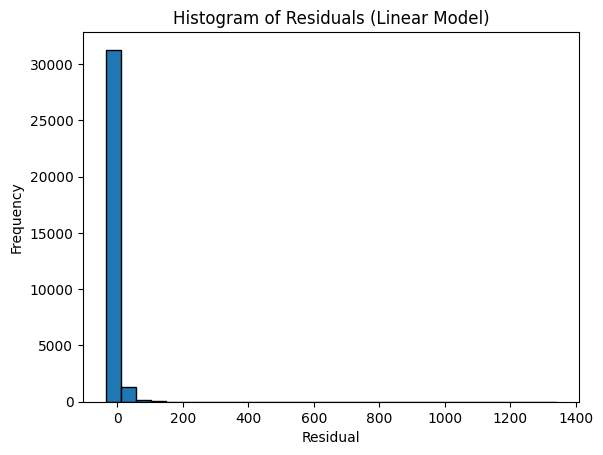

In [19]:
# Plotting histogram of residuals
residuals = model.resid
plt.hist(residuals, bins=30, edgecolor='k')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals (Linear Model)')
plt.show()

#### v. Simulate 1000 values from the joint posterior distribution of the regression coefficients. 

In [20]:
# TODO 12: extract regression coefficients and covariance matrix

beta_hat = model.params
cov_matrix = model.cov_params()

# Number of simulations
n_simulations = 1000

# Simulate beta coefficients
simulated_betas = multivariate_normal.rvs(mean=beta_hat, cov=cov_matrix, size=n_simulations)


Use a `violin plot` to display the distrubution and point-estimates of the most `statistically significant` coefficients. To pick the most significant coefficients, you can use a rule of thumb as harsh as Pr(beta>0)>0.975 | Pr(beta>0)<0.025, or as laxed as Pr(beta>0)>0.8 | Pr(beta>0)<0.2.

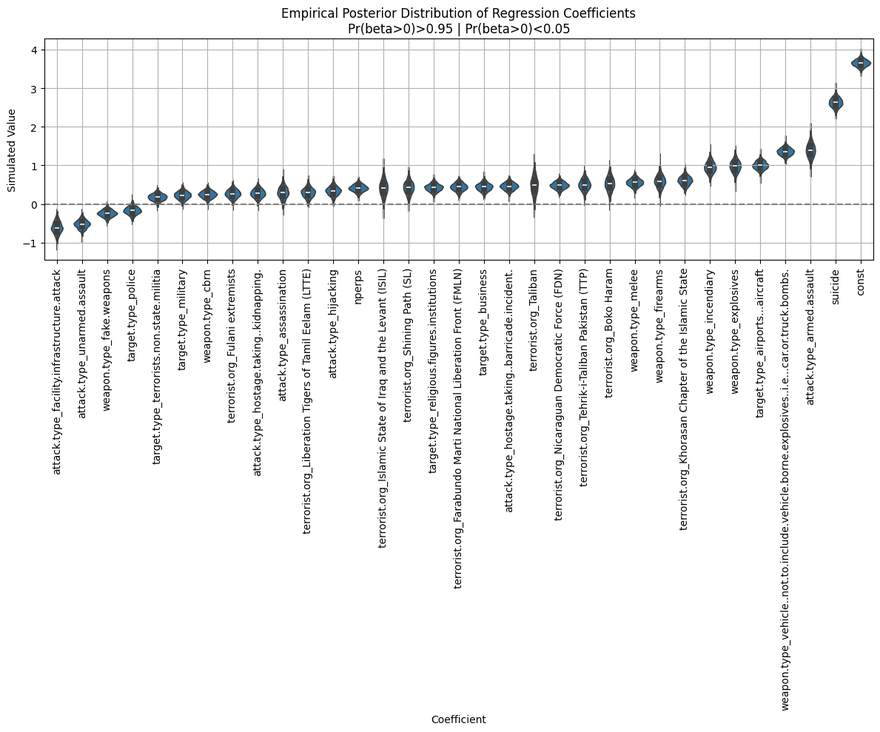

In [21]:
# # # I will do this for you on this instance, you have to repeat it for the following regressions. 

# Transform simulated_betas into a DataFrame for plotting
simulations_df = pd.DataFrame(simulated_betas, columns=model.params.index)

# Convert the DataFrame from wide to long format
long_df = simulations_df.melt(var_name='Coefficient', value_name='Value')

# Calculate the probability of coef > 0 for each coefficient
prob_greater_than_zero = long_df.groupby('Coefficient')['Value'].apply(lambda x: np.mean(x > 0)).reset_index()
prob_greater_than_zero.rename(columns={'Value': 'P(coef>0)'}, inplace=True)

# Filter coefficients based on the probability criterion
filtered_coefs = prob_greater_than_zero[
    (prob_greater_than_zero['P(coef>0)'] > 0.95) | (prob_greater_than_zero['P(coef>0)'] < 0.05)
]['Coefficient']

# Filter the long_df to include only the selected coefficients
filtered_long_df = long_df[long_df['Coefficient'].isin(filtered_coefs)]

# Calculate the median of the simulated values for each filtered coefficient
medians = filtered_long_df.groupby('Coefficient')['Value'].median().reset_index()

# Sort the filtered medians
medians_sorted = medians.sort_values(by='Value')

# Plotting the filtered and ordered coefficients
plt.figure(figsize=(12, 10))  # Adjust the figure size as needed
sns.violinplot(x='Coefficient', y='Value', data=filtered_long_df, order=medians_sorted['Coefficient'])

# Add a vertical dotted line at x = 0
plt.axhline(y=0, color='grey', linestyle='--')

# Additional customization
plt.title('Empirical Posterior Distribution of Regression Coefficients\nPr(beta>0)>0.95 | Pr(beta>0)<0.05')
plt.xticks(rotation=90)  # Rotate the x-axis labels for better readability
plt.xlabel('Coefficient')
plt.ylabel('Simulated Value')
plt.grid(True)

# Display the plot
plt.tight_layout()  # Adjust layout to not cut off labels
plt.show()

Draw 1000 samples from the posterior predictive distribution of $y$. 

In [22]:
# Initialize an array to store predictions from each simulation
predicted_counts = np.zeros((n_simulations, X_encoded_with_const.shape[0]))

# TODO 13: Generate predictions for each simulation
# Loop over the number of simulations
# 1. Calculate the predicted rate for each simulation using the simulated coefficients and the data
# 2. Generate the predicted counts by sampling from a normal distribution with the predicted rate and the model scale 
# 3. fill in the i-th position of predicted_counts with the predicted counts 
for i in range(n_simulations):
    beta_simulation = simulated_betas[i]
    predicted_rate = np.dot(X_encoded_with_const, beta_simulation)
    # Uncomment next line
    predicted_counts[i] = np.random.normal(predicted_rate,np.sqrt(model.scale))


#. Your solution here ...

Calculate the monte-carlo medians and prediction intervals. Based on these, calculate the point estimate correlation, rmse, bias and coverage. 

In [23]:
# TODO 14: Hint: Look back at your 1st workshop on linear regression
monte_carlo_medians = np.median(predicted_counts, axis=0)  # np.median(...)
prediction_intervals = np.percentile(predicted_counts, [2.5, 97.5], axis=0) # np.percentile(...)


# Calculate metrics
correlation = np.corrcoef(monte_carlo_medians, y_cleaned)[0, 1]   # np.corrcoef(...)[0, 1]
rmse = np.sqrt(mean_squared_error(y_cleaned, monte_carlo_medians)) # np.sqrt(mean_squared_error(...))
bias = np.mean(monte_carlo_medians - y_cleaned)    # np.mean(...)  # Mean prediction error
coverage = np.mean((y_cleaned >= prediction_intervals[0]) & (y_cleaned <= prediction_intervals[1])) # np.mean((...) & (...))

#. Your solution here ...

Plot the predicted values against the observed values of $y$. Display the error metrics above in the legend. 

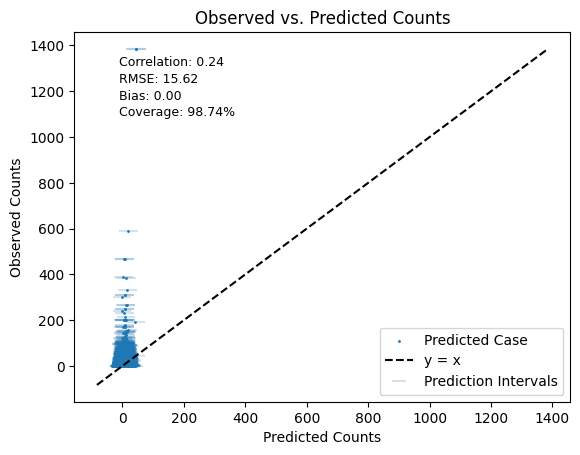

In [24]:
# # # I'll do this one for you...

# Find overall min and max for xlim and ylim
# Flatten predicted_samples to make it 1-dimensional
predicted_counts_flat = predicted_counts.flatten()
# Concatenate the flattened predicted_samples with y
combined_array = np.concatenate([predicted_counts_flat, y_cleaned])


# calculate min and max
min_val = combined_array.min()
max_val = combined_array.max()

# Plotting
scatter = plt.scatter(monte_carlo_medians, y_cleaned, s=1, alpha=1, label='Predicted Case')
errorbar = plt.errorbar(monte_carlo_medians, y_cleaned, xerr=np.abs(prediction_intervals - monte_carlo_medians), fmt='none', alpha=0.2, label='Prediction Intervals')
y_equals_x = plt.plot([min_val, max_val], [min_val, max_val], 'k--', zorder=3, label='y = x')

# Add legend with metrics
legend_labels = [
    f'Correlation: {correlation:.2f}',
    f'RMSE: {rmse:.2f}',
    f'Bias: {bias:.2f}',
    f'Coverage: {coverage:.2%}'
]

# Add legend for plot elements
plt.legend(loc='lower right')

# Text annotations for metrics
text_x = min_val + (max_val - min_val) * 0.05  # Adjust these positions as necessary
text_y_start = max_val - (max_val - min_val) * 0.05  # Starting y position for text
line_height = (max_val - min_val) * 0.05  # Adjust line height as necessary

for i, label in enumerate(legend_labels):
    plt.text(text_x, text_y_start - i * line_height, label, fontsize=9)

plt.title('Observed vs. Predicted Counts')
plt.xlabel('Predicted Counts')
plt.ylabel('Observed Counts')
plt.show()


### Part 3: Log-Linear Regression

Repeat the above from the model fitting onwards, but change the dependent variable to be on the log-scale. Apply any transformation you see fit to achieve this. 

In [25]:
from IPython.core.display import display, HTML

display(HTML("<style>.container { width:90% !important; }</style>"))

# TODO 15: Fitting the linear regression model
model = sm.OLS(y_log_cleaned, X_encoded_with_const).fit()
#. Your solution here ...

# Displaying the regression results
print(model.summary())

/var/folders/rf/c4wm9pq50j3bjhbyfct63d2h0000gn/T/ipykernel_55113/2876359795.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


                            OLS Regression Results                            
Dep. Variable:                  nkill   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     244.3
Date:                Sun, 23 Mar 2025   Prob (F-statistic):               0.00
Time:                        17:57:25   Log-Likelihood:                -38057.
No. Observations:               32775   AIC:                         7.624e+04
Df Residuals:                   32710   BIC:                         7.679e+04
Df Model:                          64                                         
Covariance Type:            nonrobust                                         
                                                                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

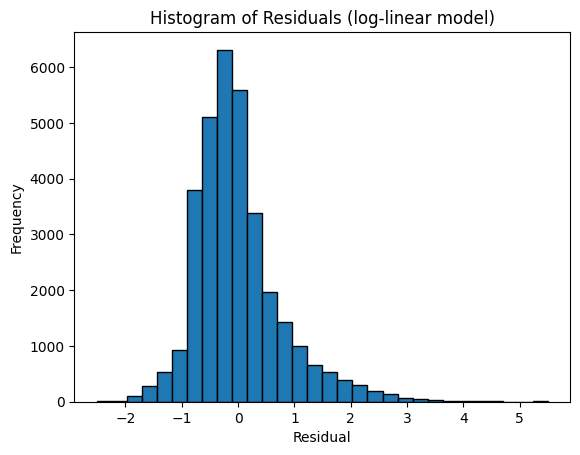

In [26]:
# Plotting histogram of residuals
residuals = model.resid
plt.hist(residuals, bins=30, edgecolor='k')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals (log-linear model)')
plt.show()

In [27]:
# TODO 16: extract regression coefficients and covariance matrix
beta_hat = model.params
cov_matrix = model.cov_params()

# Number of simulations
n_simulations = 1000

# Simulate beta coefficients
simulated_betas = multivariate_normal.rvs(mean=beta_hat, cov=cov_matrix, size=n_simulations)

#. Your solution here ...

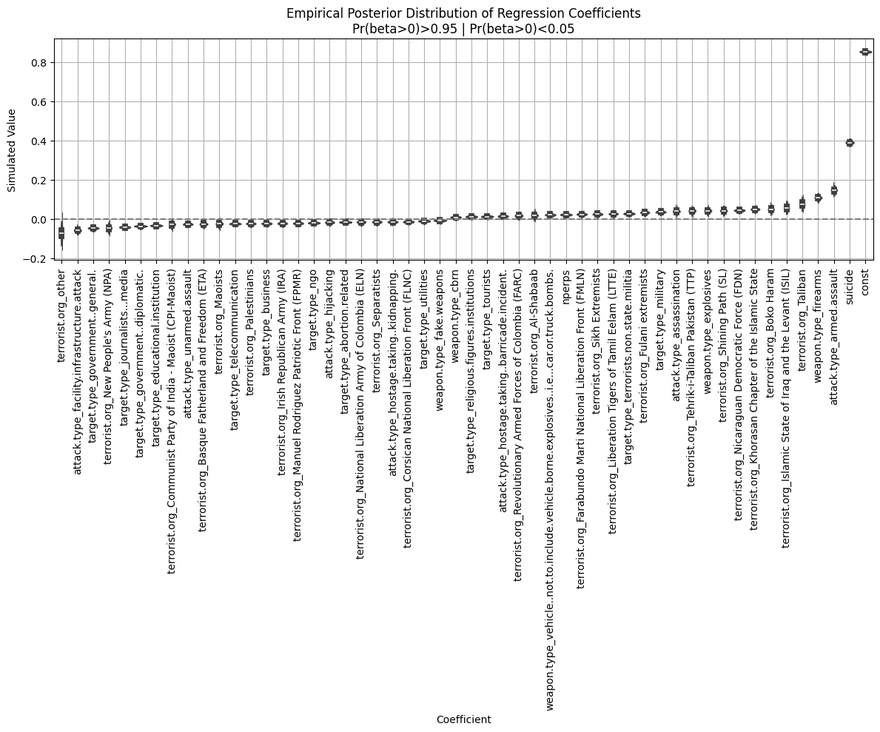

In [28]:
# TODO 17: Draw a Violin Plot

#!# BEGIN SOLUTION
# Transform simulated_betas into a DataFrame for plotting
simulations_df = pd.DataFrame(simulated_betas, columns=model.params.index)

# Convert the DataFrame from wide to long format
long_df = simulations_df.melt(var_name='Coefficient', value_name='Value')

# Calculate the probability of coef > 0 for each coefficient
prob_greater_than_zero = long_df.groupby('Coefficient')['Value'].apply(lambda x: np.mean(x > 0)).reset_index()
prob_greater_than_zero.rename(columns={'Value': 'P(coef>0)'}, inplace=True)

# Filter coefficients based on the probability criterion
filtered_coefs = prob_greater_than_zero[
    (prob_greater_than_zero['P(coef>0)'] > 0.95) | (prob_greater_than_zero['P(coef>0)'] < 0.05)
]['Coefficient']

# Filter the long_df to include only the selected coefficients
filtered_long_df = long_df[long_df['Coefficient'].isin(filtered_coefs)]

# Calculate the median of the simulated values for each filtered coefficient
medians = filtered_long_df.groupby('Coefficient')['Value'].median().reset_index()

# Sort the filtered medians
medians_sorted = medians.sort_values(by='Value')


# Plotting the filtered and ordered coefficients
plt.figure(figsize=(12, 10))  # Adjust the figure size as needed
sns.violinplot(x='Coefficient', y='Value', data=filtered_long_df, order=medians_sorted['Coefficient'])

# Add a vertical dotted line at x = 0
plt.axhline(y=0, color='grey', linestyle='--')

# Additional customization
plt.title('Empirical Posterior Distribution of Regression Coefficients\nPr(beta>0)>0.95 | Pr(beta>0)<0.05')
plt.xticks(rotation=90)  # Rotate the x-axis labels for better readability
plt.xlabel('Coefficient')
plt.ylabel('Simulated Value')
plt.grid(True)

# Display the plot
plt.tight_layout()  # Adjust layout to not cut off labels
plt.show()
#!# END SOLUTION

In [29]:
# Initialize an array to store predictions from each simulation
predicted_counts = np.zeros((n_simulations, X_encoded_with_const.shape[0]))

In [30]:
# TODO 18: Generate predictions for each simulation
# 1. Loop over the number of simulations
# 2. Calculate the predicted rate for each simulation using the simulated coefficients and the data
# 3. Generate the predicted counts by sampling from a normal distribution with the predicted rate and the model scale
# 4. Fill in the i-th position of predicted_counts with the predicted counts
for i in range(n_simulations):
    beta_simulation = simulated_betas[i]
    predicted_log_rate = np.dot(X_encoded_with_const, beta_simulation)
    # Simulate from the posterior-predictive distirbution 
    # Uncomment next line
    predicted_counts[i] = np.exp(np.random.normal(predicted_log_rate, np.sqrt(model.scale)))

    #. Your solution here ...

In [31]:
from sklearn.metrics import mean_squared_error

# TODO 19: Calculate metrics
monte_carlo_medians = np.median(predicted_counts, axis=0)
prediction_intervals = np.percentile(predicted_counts, [2.5, 97.5], axis=0)

# Calculate correlation, rmse, bias, and coverage
correlation = np.corrcoef(monte_carlo_medians, y_cleaned)[0, 1]
rmse = np.sqrt(mean_squared_error(y_cleaned, monte_carlo_medians))
bias = np.mean(monte_carlo_medians - y_cleaned)
coverage = np.mean((y_cleaned >= prediction_intervals[0]) & (y_cleaned <= prediction_intervals[1]))

#. Your solution here ...

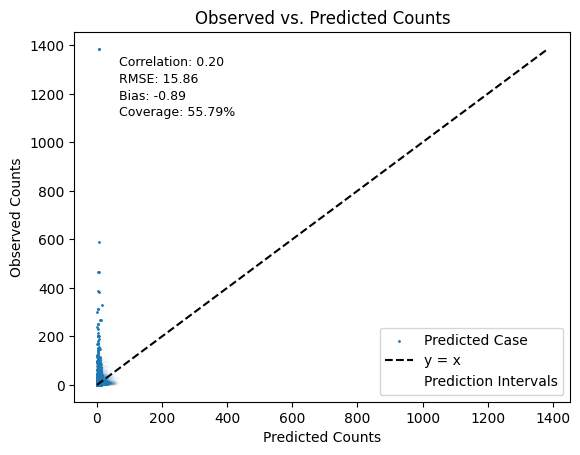

In [32]:
# # # Find overall min and max for xlim and ylim

# Flatten predicted_samples to make it 1-dimensional
predicted_counts_flat = predicted_counts.flatten()

# Concatenate the flattened predicted_samples with y
combined_array = np.concatenate([predicted_counts_flat, y_cleaned])

# calculate min and max
min_val = combined_array.min()
max_val = combined_array.max()

# Plotting
scatter = plt.scatter(monte_carlo_medians, y_cleaned, s=1, alpha=1, label='Predicted Case')
errorbar = plt.errorbar(monte_carlo_medians, y_cleaned, xerr=np.abs(prediction_intervals - monte_carlo_medians), fmt='none', alpha=0.01, label='Prediction Intervals')
y_equals_x = plt.plot([min_val, max_val], [min_val, max_val], 'k--', zorder=3, label='y = x')

# Add legend with metrics
legend_labels = [
    f'Correlation: {correlation:.2f}',
    f'RMSE: {rmse:.2f}',
    f'Bias: {bias:.2f}',
    f'Coverage: {coverage:.2%}'
]

# Add legend for plot elements
plt.legend(loc='lower right')

# Text annotations for metrics
text_x = min_val + (max_val - min_val) * 0.05  # Adjust these positions as necessary
text_y_start = max_val - (max_val - min_val) * 0.05  # Starting y position for text
line_height = (max_val - min_val) * 0.05  # Adjust line height as necessary

for i, label in enumerate(legend_labels):
    plt.text(text_x, text_y_start - i * line_height, label, fontsize=9)

plt.title('Observed vs. Predicted Counts')
plt.xlabel('Predicted Counts')
plt.ylabel('Observed Counts')
plt.show()


### Part 4: Poisson Regression

Repeat the above from the model fitting onwards, but change the distribution of the depedent variable from normal to Poisson. You can fit a poisson regression using the GLM module of the statsmodels library. Comment on which of the three regression models is most useful for this application and why. 

In [33]:
from statsmodels.api import GLM, Poisson
from IPython.core.display import display, HTML

display(HTML("<style>.container { width:90% !important; }</style>"))

# TODO 20: Fitting the linear regression model
# use function GLM with family=sm.families.Poisson()
model = sm.GLM(y_cleaned, X_encoded_with_const, family=sm.families.Poisson()).fit()

#. Your solution here ...

# Displaying the regression results
print(model.summary())

/var/folders/rf/c4wm9pq50j3bjhbyfct63d2h0000gn/T/ipykernel_55113/345226668.py:2: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  nkill   No. Observations:                32775
Model:                            GLM   Df Residuals:                    32710
Model Family:                 Poisson   Df Model:                           64
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.5821e+05
Date:                Sun, 23 Mar 2025   Deviance:                   2.5765e+05
Time:                        17:57:34   Pearson chi2:                 9.32e+05
No. Iterations:                    17   Pseudo R-squ. (CS):             0.9670
Covariance Type:            nonrobust                                         
                                                                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [34]:
# TODO 21: extract regression coefficients and covariance matrix

#!# BEGIN SOLUTION
# extract and plot regression coefficients 
beta_mean = model.params
beta_cov = model.cov_params()

# Number of simulations
n_simulations = 1000

# Simulate beta coefficients
simulated_betas = multivariate_normal.rvs(mean=beta_mean, cov=beta_cov, size=n_simulations)
#!# END SOLUTION

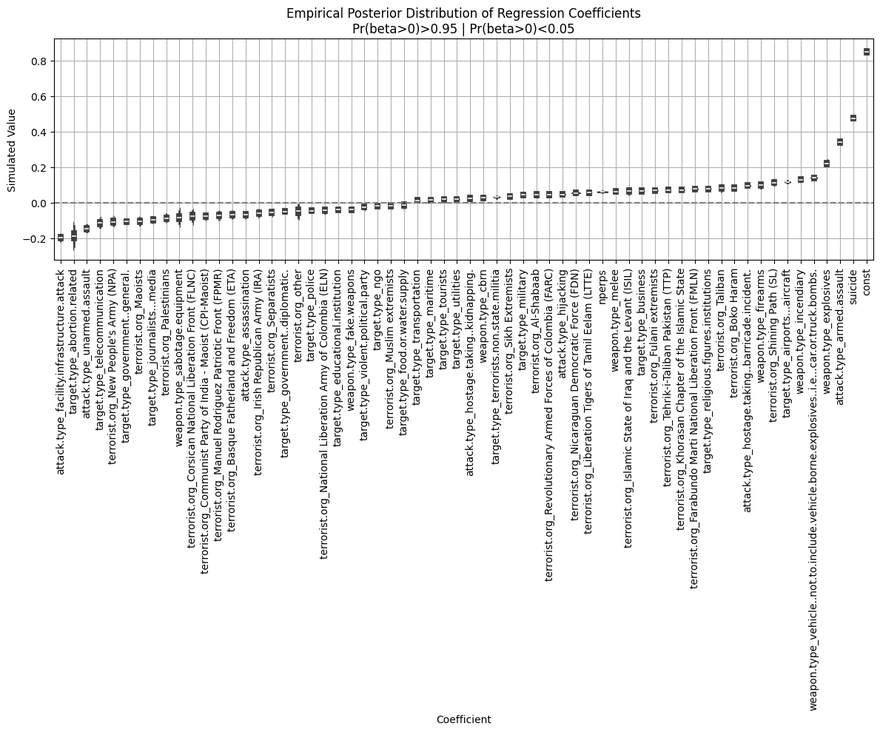

In [35]:
# Transform simulated_betas into a DataFrame for plotting
simulations_df = pd.DataFrame(simulated_betas, columns=model.params.index)

# Convert the DataFrame from wide to long format
long_df = simulations_df.melt(var_name='Coefficient', value_name='Value')

# Calculate the probability of coef > 0 for each coefficient
prob_greater_than_zero = long_df.groupby('Coefficient')['Value'].apply(lambda x: np.mean(x > 0)).reset_index()
prob_greater_than_zero.rename(columns={'Value': 'P(coef>0)'}, inplace=True)

# Filter coefficients based on the probability criterion
filtered_coefs = prob_greater_than_zero[
    (prob_greater_than_zero['P(coef>0)'] > 0.95) | (prob_greater_than_zero['P(coef>0)'] < 0.05)
]['Coefficient']

# Filter the long_df to include only the selected coefficients
filtered_long_df = long_df[long_df['Coefficient'].isin(filtered_coefs)]

# Calculate the median of the simulated values for each filtered coefficient
medians = filtered_long_df.groupby('Coefficient')['Value'].median().reset_index()

# Sort the filtered medians
medians_sorted = medians.sort_values(by='Value')


# Plotting the filtered and ordered coefficients
plt.figure(figsize=(12, 10))  # Adjust the figure size as needed
sns.violinplot(x='Coefficient', y='Value', data=filtered_long_df, order=medians_sorted['Coefficient'])

# Add a vertical dotted line at x = 0
plt.axhline(y=0, color='grey', linestyle='--')

# Additional customization
plt.title('Empirical Posterior Distribution of Regression Coefficients\nPr(beta>0)>0.95 | Pr(beta>0)<0.05')
plt.xticks(rotation=90)  # Rotate the x-axis labels for better readability
plt.xlabel('Coefficient')
plt.ylabel('Simulated Value')
plt.grid(True)

# Display the plot
plt.tight_layout()  # Adjust layout to not cut off labels
plt.show()

In [36]:
# TODO 22: Initialize an array to store predictions from each simulation
predicted_counts = np.zeros((n_simulations, X_encoded_with_const.shape[0]))

#. Your solution here ...

In [37]:
# Generate predictions for each simulation
for i in range(n_simulations):
    beta_simulation = simulated_betas[i]
    predicted_rate = np.exp(np.dot(X_encoded_with_const, beta_simulation))
    predicted_counts[i] = np.random.poisson(predicted_rate)

In [38]:
from sklearn.metrics import mean_squared_error

# TODO 23:Calculate metrics

#. Your solution here ...
monte_carlo_medians = np.median(predicted_counts, axis=0)
prediction_intervals = np.percentile(predicted_counts, [2.5, 97.5], axis=0)

correlation = np.corrcoef(monte_carlo_medians, y_cleaned)[0, 1]
rmse = np.sqrt(mean_squared_error(y_cleaned, monte_carlo_medians))
bias = np.mean(monte_carlo_medians - y_cleaned)
coverage = np.mean((y_cleaned >= prediction_intervals[0]) & (y_cleaned <= prediction_intervals[1]))

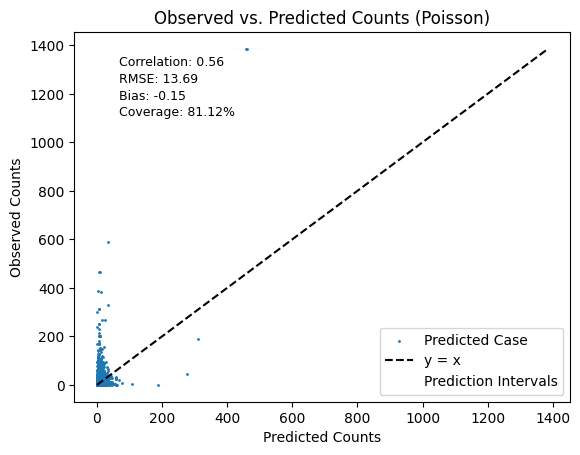

In [39]:
# TODO 24: Plot Predictions v. Observations

#. Your solution here ...
predicted_counts_flat = predicted_counts.flatten()
combined_array = np.concatenate([predicted_counts_flat, y_cleaned])
min_val = combined_array.min()
max_val = combined_array.max()

plt.scatter(monte_carlo_medians, y_cleaned, s=1, alpha=1, label='Predicted Case')
plt.errorbar(monte_carlo_medians, y_cleaned, xerr=np.abs(prediction_intervals - monte_carlo_medians), fmt='none', alpha=0.01, label='Prediction Intervals')
plt.plot([min_val, max_val], [min_val, max_val], 'k--', zorder=3, label='y = x')

legend_labels = [
    f'Correlation: {correlation:.2f}',
    f'RMSE: {rmse:.2f}',
    f'Bias: {bias:.2f}',
    f'Coverage: {coverage:.2%}'
]

plt.legend(loc='lower right')
text_x = min_val + (max_val - min_val) * 0.05
text_y_start = max_val - (max_val - min_val) * 0.05
line_height = (max_val - min_val) * 0.05

for i, label in enumerate(legend_labels):
    plt.text(text_x, text_y_start - i * line_height, label, fontsize=9)

plt.title('Observed vs. Predicted Counts (Poisson)')
plt.xlabel('Predicted Counts')
plt.ylabel('Observed Counts')
plt.show()

Comment on which of the three regression models is most useful for this application and why.

#!# BEGIN ANSWER
The Poisson regression model displays better correlation and RMSE, largely driven by the ability to more accurately predict high-kill incidents. 
#!# END ANSWER

# SUMMATIVE ASSESSMENT

Now pick a dataset of your choice. Please ensure your dataset is a csv file under 100MB named sem4_portfolio_2_data_custom.csv

Apply any of the relevant models to a count datasets of your choice, investigate predictive power and interpret the models exhaustively.

## Hitters Baseball Data - MLB Data from 1986 - 1987
https://www.kaggle.com/datasets/mathchi/hitters-baseball-data

In [40]:
# Do NOT modify the contents of this cell. Start your customization in the next one!
custom_data_path = "sem4_portfolio_2_data_custom.csv"
custom_df = pd.read_csv(custom_data_path)

In [41]:
# Feel free to add any code or markdown cells between here and the final code cell, and fill them with your custom analysis!

### 0) Import Necessary Libraries

In [42]:
# Import Necessary Libraries
import os
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy import stats
from scipy.stats import multivariate_normal, bernoulli, beta, norm
from scipy.stats import ks_2samp
from scipy.special import expit as logistic_sigmoid
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.metrics import brier_score_loss
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.metrics import balanced_accuracy_score, brier_score_loss, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.model_selection import KFold
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

# Set display option to avoid scientific notation in pandas, show up to 5 decimal points
pd.set_option('display.float_format', lambda x: '%.5f' % x)
# and numpy
np.set_printoptions(suppress=True, precision=5)

### 1) Data Pre-Processing

In [43]:
# Overview of data
custom_df.head(1000)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.00000,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.00000,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.00000,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.50000,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.00000,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.00000,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.00000,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.00000,A


In [44]:
# Check for missing values
print("\nMissing values in each column:")
print(custom_df.isna().sum())


Missing values in each column:
AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64


#### Handle Missing Values

In [45]:
# Impute missing values in Salary with the median
custom_df_clean = custom_df.copy()
custom_df_clean['Salary'] = custom_df_clean['Salary'].fillna(custom_df_clean['Salary'].median())

# Verify the number of remaining rows and missing values
print(f"Rows after imputation: {len(custom_df_clean)}")
print("\nMissing values in each column after cleaning:")
print(custom_df_clean.isnull().sum())

Rows after imputation: 322

Missing values in each column after cleaning:
AtBat        0
Hits         0
HmRun        0
Runs         0
RBI          0
Walks        0
Years        0
CAtBat       0
CHits        0
CHmRun       0
CRuns        0
CRBI         0
CWalks       0
League       0
Division     0
PutOuts      0
Assists      0
Errors       0
Salary       0
NewLeague    0
dtype: int64


#### Select Features and Response & Encode Categorical Variables

In [46]:
# Define the response variable (count data) and predictor variables
Y_cols = ['HmRun']  # Response: Number of home runs (count variable)
X_cols = [
    'AtBat', 'Hits', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 
    'CRuns', 'CRBI', 'CWalks', 'League', 'Division', 'PutOuts', 'Assists', 
    'Errors', 'Salary', 'NewLeague'
]  # Predictors: All other relevant columns

# Create a combined DataFrame with only the selected columns
YX = custom_df_clean[Y_cols + X_cols]

# Encode categorical variables (League, Division, NewLeague) using one-hot encoding
categorical_cols = ['League', 'Division', 'NewLeague']
YX_encoded = pd.get_dummies(YX, columns=categorical_cols, drop_first=True)

# Update X_cols to reflect the new dummy columns
X_cols = [col for col in YX_encoded.columns if col not in Y_cols]

# Display the updated columns and shape
print(f"Updated Y_cols: {Y_cols}")
print(f"Updated X_cols: {X_cols}")
print(f"Shape of YX_encoded: {YX_encoded.shape}")
print("\nFirst few rows of YX_encoded:")
print(YX_encoded.head())

Updated Y_cols: ['HmRun']
Updated X_cols: ['AtBat', 'Hits', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'Salary', 'League_N', 'Division_W', 'NewLeague_N']
Shape of YX_encoded: (322, 19)

First few rows of YX_encoded:
   HmRun  AtBat  Hits  Runs  RBI  Walks  Years  CAtBat  CHits  CRuns  CRBI  \
0      1    293    66    30   29     14      1     293     66     30    29   
1      7    315    81    24   38     39     14    3449    835    321   414   
2     18    479   130    66   72     76      3    1624    457    224   266   
3     20    496   141    65   78     37     11    5628   1575    828   838   
4     10    321    87    39   42     30      2     396    101     48    46   

   CWalks  PutOuts  Assists  Errors    Salary  League_N  Division_W  \
0      14      446       33      20 425.00000     False       False   
1     375      632       43      10 475.00000      True        True   
2     263      880       82      1

#### Clean Zero-Variance Columns

In [47]:
# Remove zero-variance columns (now all columns are numeric after encoding)
variances = YX_encoded.var(axis=0)  # Calculate variance for all columns
kept_columns = (variances != 0)  # Mask for columns with non-zero variance

# Keep only the columns with non-zero variance
YX_variable = YX_encoded.loc[:, kept_columns]

# Update X_cols and Y_cols to reflect kept columns
Y_cols = [col for col in Y_cols if kept_columns.get(col, False)]
X_cols = [col for col in X_cols if kept_columns.get(col, False)]

# Display the updated column lists and shape
print(f"Updated Y_cols: {Y_cols}")
print(f"Updated X_cols: {X_cols}")
print(f"Shape of YX_variable: {YX_variable.shape}")

Updated Y_cols: ['HmRun']
Updated X_cols: ['AtBat', 'Hits', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'Salary', 'League_N', 'Division_W', 'NewLeague_N']
Shape of YX_variable: (322, 19)


#### Transform the Response

In [48]:
# Transform the response variable with log(1 + x) to handle zeros and skewness
log_Y = np.log(YX_variable[Y_cols[0]] + 1)

# Display the first few transformed values
print(f"\nFirst few log-transformed HmRun values: {log_Y.head().values}")


First few log-transformed HmRun values: [0.69315 2.07944 2.94444 3.04452 2.3979 ]


#### Standardize Predictors

In [49]:
# Separate predictors and standardize continuous variables
X = YX_variable[X_cols]
scaler = StandardScaler()

# Identify continuous (numeric) columns (exclude dummy variables)
X_continuous_cols = [
    col for col in X_cols if col not in ['League_N', 'Division_W', 'NewLeague_N']
]
X_continuous = X[X_continuous_cols]

# Standardize continuous predictors
X_continuous_scaled = scaler.fit_transform(X_continuous)

# Combine scaled continuous and dummy variables (already 0/1 encoded)
X_categorical = X[['League_N', 'Division_W', 'NewLeague_N']]
X_scaled = np.hstack((X_continuous_scaled, X_categorical))

# Convert back to DataFrame for compatibility
X_scaled_df = pd.DataFrame(X_scaled, columns=X_continuous_cols + ['League_N', 'Division_W', 'NewLeague_N'])

# Display the first few rows of standardized predictors
print("\nFirst few rows of standardized predictors:")
print(X_scaled_df.head())


First few rows of standardized predictors:
     AtBat     Hits     Runs      RBI    Walks    Years   CAtBat    CHits  \
0 -0.57407 -0.75513 -0.80473 -0.72831 -1.14517 -1.31019 -1.01512 -0.99712   
1 -0.43044 -0.43173 -1.03565 -0.38383  0.01193  1.33292  0.34488  0.17970   
2  0.64029  0.62470  0.58075  0.91755  1.72444 -0.90356 -0.44156 -0.39876   
3  0.75128  0.86186  0.54227  1.14720 -0.08064  0.72297  1.28386  1.31215   
4 -0.39126 -0.30237 -0.45836 -0.23072 -0.40463 -1.10688 -0.97074 -0.94356   

     CRuns     CRBI   CWalks  PutOuts  Assists   Errors   Salary  League_N  \
0 -0.98564 -0.90507 -0.92348  0.56040 -0.54092  1.88090 -0.22142   0.00000   
1 -0.11330  0.25212  0.43039  1.22405 -0.46774  0.30819 -0.09923   1.00000   
2 -0.40408 -0.19272  0.01035  2.10891 -0.18232  0.93727 -0.08701   0.00000   
3  1.40655  1.52654  0.35163 -0.31733 -0.70193 -0.79270 -0.03813   1.00000   
4 -0.93168 -0.85397 -0.85222  1.84131 -0.48970 -0.63543 -1.03646   1.00000   

   Division_W  NewLeague

#### Split into Training and Test Sets

In [50]:
# Split the data into training and test sets
X_train, X_test, log_Y_train, log_Y_test, idx_train, idx_test = train_test_split(
    X_scaled, log_Y, YX_variable.index, test_size=0.3, random_state=42
)

# Display the shapes of the splits
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"log_Y_train shape: {log_Y_train.shape}")
print(f"log_Y_test shape: {log_Y_test.shape}")


X_train shape: (225, 18)
X_test shape: (97, 18)
log_Y_train shape: (225,)
log_Y_test shape: (97,)


#### Histogram of Raw 'HmRun'

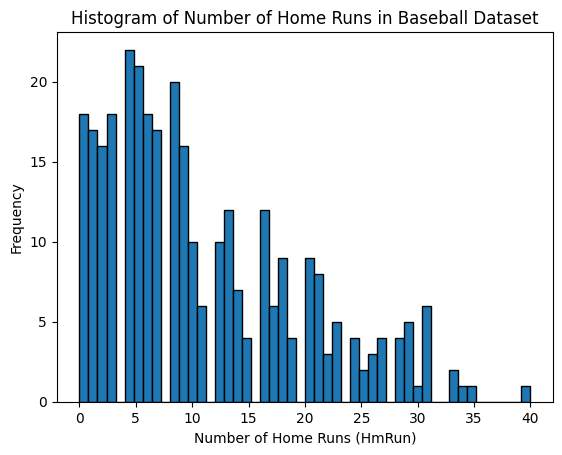

In [51]:
# Plot the histogram of Raw HmRun
plt.hist(YX_variable['HmRun'], bins=50, edgecolor='black')
plt.xlabel('Number of Home Runs (HmRun)')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Home Runs in Baseball Dataset')
plt.show()

- The distribution of the home runs is clearly skewed and peaked around 5-10 home runs, with a long tail extending to 40. This indicates that most players at least a few home runs. The distribution is non-Gaussian due to its right-skewed nature.

#### Histogram of Log-Transformed 'HmRun'

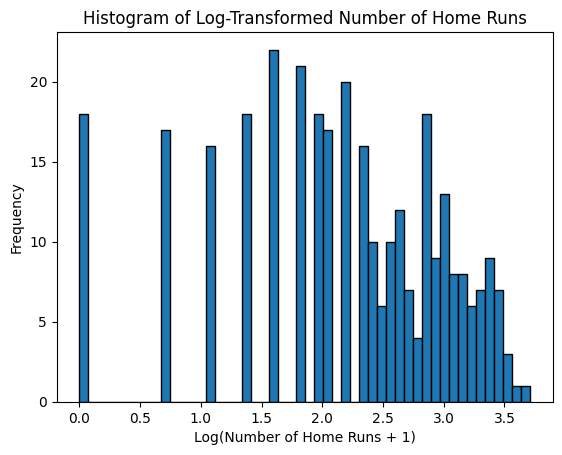

In [52]:
# Plot the histogram of the log of HmRun
plt.hist(np.log(YX_variable['HmRun'] + 1), bins=50, edgecolor='black')
plt.xlabel('Log(Number of Home Runs + 1)')
plt.ylabel('Frequency')
plt.title('Histogram of Log-Transformed Number of Home Runs')
plt.show()

- The distribution of the log-transformed number of home runs is less skewed than the raw data and it is peaked around 1.5-2.0, with smoother decline extending to 3.5. Unlike the raw data, the log-transformation reduces the prominence of the peak and tail, but the distribution remains non-Gaussian due to its asymmetric shape.

### 2) Linear Regression

#### Create a Composite Variable and Select Relevant Variables

In [53]:
# Create a composite variable for total offensive performance (no equivalent to nuclear weapons in baseball data)
YX_variable['total_performance'] = YX_variable['Hits'] + YX_variable['Runs'] + YX_variable['RBI']

# Select relevant variables including the target variable
data = YX_variable[['HmRun', 'total_performance', 'League_N']]

# Display the first few rows of the selected data for verification
print("\nFirst few rows of selected data:")
print(data.head())


First few rows of selected data:
   HmRun  total_performance  League_N
0      1                125     False
1      7                143      True
2     18                268     False
3     20                284      True
4     10                168      True


#### Count Players per Years & Find Elbow Point

Elbow point at: 1
Elbow point at: 1


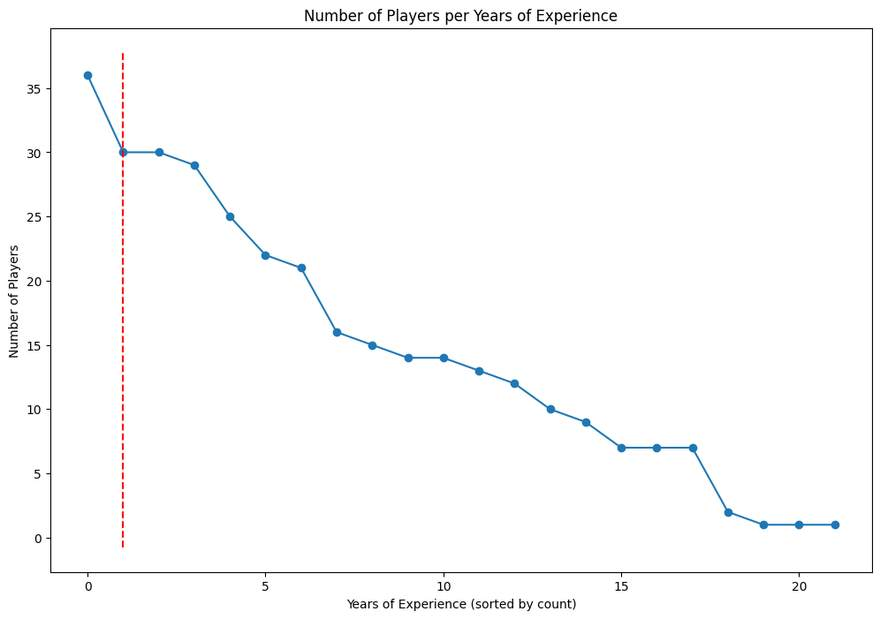

In [54]:
from kneed import KneeLocator

# Count players per years of experience and sort by count
years_counts = YX_variable['Years'].value_counts().sort_values(ascending=False)
x = range(len(years_counts))
y = years_counts.values

# Use KneeLocator to find elbow
kl = KneeLocator(x, y, curve='convex', direction='decreasing')
elbow_point = kl.elbow

print(f"Elbow point at: {elbow_point}")

print(f"Elbow point at: {elbow_point}")

# Plotting
plt.figure(figsize=(12, 8))
plt.plot(x, y, marker='o', linestyle='-')
plt.vlines(elbow_point, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', color='red')
plt.xlabel('Years of Experience (sorted by count)')
plt.ylabel('Number of Players')
plt.title('Number of Players per Years of Experience')

plt.show()

#### Identify the most Common years of experience and modify categories

In [55]:
# Identify the most common years of experience
n_top = 5  # Keep top 5 years for more variability
most_common_years = years_counts.index[:n_top].tolist()

# Modify the 'Years' column
YX_variable['Years'] = YX_variable['Years'].apply(lambda year: year if year in most_common_years else 'other')

# Verify the distribution
print("Distribution of modified 'Years':")
print(YX_variable['Years'].value_counts())

Distribution of modified 'Years':
Years
other    172
4         36
6         30
5         30
3         29
2         25
Name: count, dtype: int64


#### Design Matrix and Dependend Variable Vector

In [56]:
# TODO 7: Select predictors and target variable
X = YX_variable[['HmRun', 'total_performance', 'League_N', 'Years', 'Salary', 'CAtBat',
                 'CHits', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors',
                 'Division_W', 'NewLeague_N']]

# Drop rows with missing values
data_cleaned = X.dropna()

X = YX_variable[['HmRun', 'total_performance', 'League_N', 'Years', 'Salary', 'CAtBat',
                 'CHits', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors',
                 'Division_W', 'NewLeague_N']]
data_cleaned = X.dropna()

# Separate predictors and target
y_cleaned = data_cleaned['HmRun']
y_log_cleaned = np.log(data_cleaned['HmRun'] + 1)
X_cleaned = data_cleaned.drop(columns=['HmRun'])

# Debug: Check initial columns
print("Columns in X_cleaned:", X_cleaned.columns.tolist())

Columns in X_cleaned: ['total_performance', 'League_N', 'Years', 'Salary', 'CAtBat', 'CHits', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'Division_W', 'NewLeague_N']


#### One-Hot Encoding Categorical Variables

In [57]:
# TODO 8: One-hot encoding categorical variables
X_encoded = pd.get_dummies(X_cleaned[['League_N', 'Years', 'Division_W', 'NewLeague_N']], drop_first=True).astype(int)
X_encoded = pd.concat([X_encoded, X_cleaned[['total_performance', 'Salary', 'CAtBat', 'CHits', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors']]], axis=1)

# Debug: Check encoded columns
print("Columns in X_encoded:", X_encoded.columns.tolist())

Columns in X_encoded: ['League_N', 'Division_W', 'NewLeague_N', 'Years_3', 'Years_4', 'Years_5', 'Years_6', 'Years_other', 'total_performance', 'Salary', 'CAtBat', 'CHits', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors']


#### Variance Thresholding

In [58]:
# Drop variables with 0 variability
selector = VarianceThreshold()
X_encoded_var_filtered = selector.fit_transform(X_encoded)
X_encoded_var_filtered = X_encoded.iloc[:, selector.get_support(indices=True)]

# Debug: Check columns before and after thresholding
print("Columns before variance thresholding:", X_encoded.columns.tolist())
print("Columns after variance thresholding:", X_encoded_var_filtered.columns.tolist())

Columns before variance thresholding: ['League_N', 'Division_W', 'NewLeague_N', 'Years_3', 'Years_4', 'Years_5', 'Years_6', 'Years_other', 'total_performance', 'Salary', 'CAtBat', 'CHits', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors']
Columns after variance thresholding: ['League_N', 'Division_W', 'NewLeague_N', 'Years_3', 'Years_4', 'Years_5', 'Years_6', 'Years_other', 'total_performance', 'Salary', 'CAtBat', 'CHits', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors']


#### Correlation Matrix & Drop Highly Correlated Features

In [59]:
# Calculate correlation matrix
corr_matrix = X_encoded_var_filtered.corr().abs()

# Select upper triangle
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns to drop
to_drop = []
for column in upper_tri.columns:
    for row in upper_tri.index:
        if upper_tri.loc[row, column] > 0.9 and column not in to_drop and row not in to_drop:
            to_drop.append(column)
            break

# Drop highly correlated features
X_encoded_final = X_encoded_var_filtered.drop(columns=to_drop)

# Debug: Check dropped columns
print("Columns dropped due to multicollinearity:", to_drop)
print("Columns in X_encoded_final:", X_encoded_final.columns.tolist())

Columns dropped due to multicollinearity: ['CHits', 'CRuns', 'CRBI', 'CWalks']
Columns in X_encoded_final: ['League_N', 'Division_W', 'NewLeague_N', 'Years_3', 'Years_4', 'Years_5', 'Years_6', 'Years_other', 'total_performance', 'Salary', 'CAtBat', 'PutOuts', 'Assists', 'Errors']


#### Standardize Features to help with interpretation

In [60]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_encoded_final),
    columns=X_encoded_final.columns,
    index=X_encoded_final.index
)

#### Fit Linear Regression Model

Linear Regression Results:
                            OLS Regression Results                            
Dep. Variable:                  HmRun   R-squared:                       0.600
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     32.90
Date:                Sun, 23 Mar 2025   Prob (F-statistic):           7.94e-53
Time:                        17:57:43   Log-Likelihood:                -1005.8
No. Observations:                 322   AIC:                             2042.
Df Residuals:                     307   BIC:                             2098.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const      

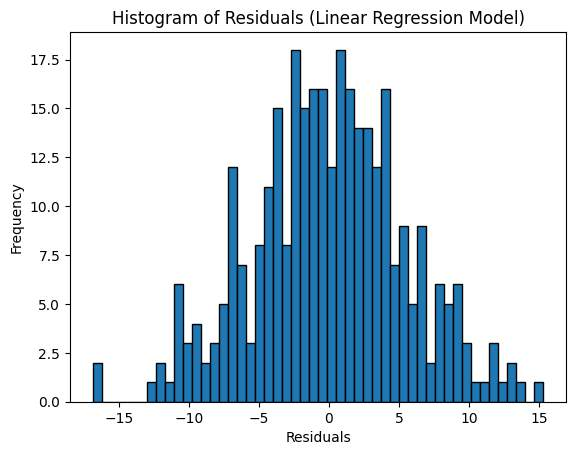

In [61]:
# Adding a constant
X_encoded_with_const = sm.add_constant(X_train_scaled)

# Fitting the linear regression model
model_linear = sm.OLS(y_cleaned, X_encoded_with_const).fit()

# Display regression results
print("Linear Regression Results:")
print(model_linear.summary())

# Plot residuals
plt.hist(model_linear.resid, bins=50, edgecolor='black')
plt.title('Histogram of Residuals (Linear Regression Model)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

#### Extract Regression Coefficients and Covariance Matrix (1000)

In [62]:
# Extract regression coefficients and covariance matrix
beta_hat = model_linear.params
cov_matrix = model_linear.cov_params()

# Number of simulations
n_simulations = 1000

# Simulate beta coefficients
simulated_betas = multivariate_normal.rvs(mean=beta_hat, cov=cov_matrix, size=n_simulations)

# Verify coefficients
print("Number of coefficients in beta_hat:", len(beta_hat))
print("Coefficient names:", beta_hat.index.tolist())

Number of coefficients in beta_hat: 15
Coefficient names: ['const', 'League_N', 'Division_W', 'NewLeague_N', 'Years_3', 'Years_4', 'Years_5', 'Years_6', 'Years_other', 'total_performance', 'Salary', 'CAtBat', 'PutOuts', 'Assists', 'Errors']


#### Simulate and Plot Empirical Posterior Distribution

Probability of coef > 0 for each coefficient:
          Coefficient  P(coef>0)
0             Assists    0.00000
1              CAtBat    0.89300
2          Division_W    0.77400
3              Errors    0.95800
4            League_N    0.72200
5         NewLeague_N    0.03500
6             PutOuts    0.66200
7              Salary    0.70600
8             Years_3    0.89800
9             Years_4    0.21300
10            Years_5    0.03400
11            Years_6    0.45400
12        Years_other    0.20400
13              const    1.00000
14  total_performance    1.00000


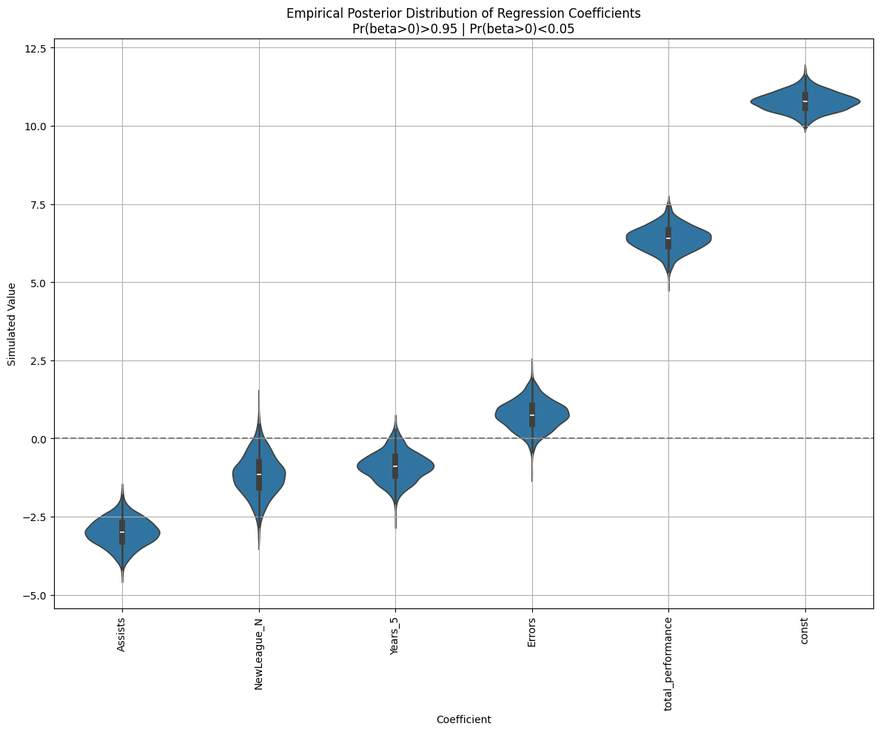

In [63]:
# Transform simulated_betas into a DataFrame for plotting
simulations_df = pd.DataFrame(simulated_betas, columns=model_linear.params.index)

# Convert the DataFrame from wide to long format
long_df = simulations_df.melt(var_name='Coefficient', value_name='Value')

# Calculate the probability of coef > 0 for each coefficient
prob_greater_than_zero = long_df.groupby('Coefficient')['Value'].apply(lambda x: np.mean(x > 0)).reset_index()
prob_greater_than_zero.rename(columns={'Value': 'P(coef>0)'}, inplace=True)
print("Probability of coef > 0 for each coefficient:")
print(prob_greater_than_zero)

# Filter coefficients based on the probability criterion
filtered_coefs = prob_greater_than_zero[
    (prob_greater_than_zero['P(coef>0)'] > 0.95) | (prob_greater_than_zero['P(coef>0)'] < 0.05)
]['Coefficient']

# Filter the long_df to include only the selected coefficients
filtered_long_df = long_df[long_df['Coefficient'].isin(filtered_coefs)]

# Calculate the median of the simulated values for each filtered coefficient
medians = filtered_long_df.groupby('Coefficient')['Value'].median().reset_index()

# Sort the filtered medians
medians_sorted = medians.sort_values(by='Value')

# Plotting the filtered and ordered coefficients
plt.figure(figsize=(12, 10))  # Adjust the figure size as needed
sns.violinplot(x='Coefficient', y='Value', data=filtered_long_df, order=medians_sorted['Coefficient'])

# Add a horizontal dotted line at y = 0
plt.axhline(y=0, color='grey', linestyle='--')

# Additional customization
plt.title('Empirical Posterior Distribution of Regression Coefficients\nPr(beta>0)>0.95 | Pr(beta>0)<0.05')
plt.xticks(rotation=90)  # Rotate the x-axis labels for better readability
plt.xlabel('Coefficient')
plt.ylabel('Simulated Value')
plt.grid(True)

# Display the plot
plt.tight_layout()  # Adjust layout to not cut off labels
plt.show()

#### Draw 1000 samples from the Posterior Predictive Distribution of y

In [64]:

# Initialize an array to store predictions from each simulation
predicted_counts = np.zeros((n_simulations, X_encoded_with_const.shape[0]))

# Loop over the number of simulations
# 1. Calculate the predicted rate for each simulation using the simulated coefficients and the data
# 2. Generate the predicted counts by sampling from a normal distribution with the predicted rate and the model scale 
# 3. fill in the i-th position of predicted_counts with the predicted counts 
for i in range(n_simulations):
    beta_simulation = simulated_betas[i]
    predicted_rate = np.dot(X_encoded_with_const, beta_simulation)
    # Uncomment next line
    predicted_counts[i] = np.random.normal(predicted_rate, np.sqrt(model_linear.scale))

# Verify shape of predicted_counts
print("Shape of predicted_counts:", predicted_counts.shape)

Shape of predicted_counts: (1000, 322)


#### Monte Carlo Medians, Prediction Intervals, and Metrics
- Calculate the monte-carlo medians and prediction intervals. Based on these, calculate the point estimate correlation, rmse, bias and coverage.

In [65]:
# Calculate the monte-carlo medians and prediction intervals. Based on these, calculate the point estimate correlation, rmse, bias and coverage.

# Look back at your 1st workshop on linear regression
monte_carlo_medians = np.median(predicted_counts, axis=0)  # Median across simulations for each observation
prediction_intervals = np.percentile(predicted_counts, [2.5, 97.5], axis=0)  # 95% interval

# Calculate metrics
correlation = np.corrcoef(monte_carlo_medians, y_cleaned)[0, 1]  # Pearson correlation between predicted and observed
rmse = np.sqrt(mean_squared_error(y_cleaned, monte_carlo_medians))  # Root mean squared error
bias = np.mean(monte_carlo_medians - y_cleaned)  # Mean prediction error
coverage = np.mean((y_cleaned >= prediction_intervals[0]) & (y_cleaned <= prediction_intervals[1]))  # Proportion of observed within 95% interval


# Verify metrics
print("Monte Carlo Medians Shape:", monte_carlo_medians.shape)
print(f"Correlation: {correlation:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Bias: {bias:.2f}")
print(f"Coverage: {coverage:.2%}")

Monte Carlo Medians Shape: (322,)
Correlation: 0.77
RMSE: 5.54
Bias: -0.00
Coverage: 95.65%


#### Predicted vs. Observed Counts of y

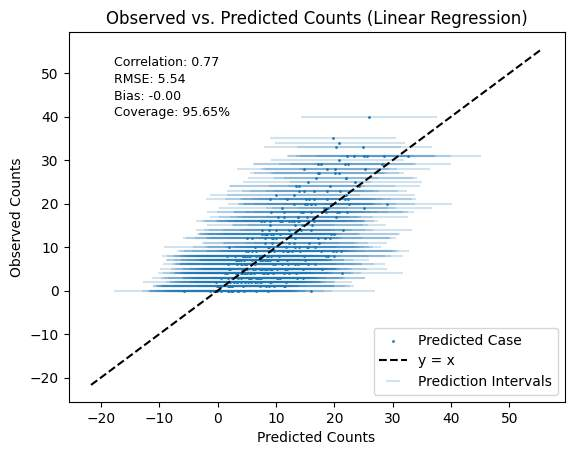

In [66]:
# Find overall min and max for xlim and ylim
predicted_counts_flat = predicted_counts.flatten()
combined_array = np.concatenate([predicted_counts_flat, y_cleaned])

# Calculate min and max
min_val = combined_array.min()
max_val = combined_array.max()

# Plotting
scatter = plt.scatter(monte_carlo_medians, y_cleaned, s=1, alpha=1, label='Predicted Case')
errorbar = plt.errorbar(monte_carlo_medians, y_cleaned, xerr=np.abs(prediction_intervals - monte_carlo_medians), fmt='none', alpha=0.2, label='Prediction Intervals')
y_equals_x = plt.plot([min_val, max_val], [min_val, max_val], 'k--', zorder=3, label='y = x')

# Add legend with metrics
legend_labels = [
    f'Correlation: {correlation:.2f}',
    f'RMSE: {rmse:.2f}',
    f'Bias: {bias:.2f}',
    f'Coverage: {coverage:.2%}'
]

# Add legend for plot elements
plt.legend(loc='lower right')

# Text annotations for metrics
text_x = min_val + (max_val - min_val) * 0.05
text_y_start = max_val - (max_val - min_val) * 0.05
line_height = (max_val - min_val) * 0.05

for i, label in enumerate(legend_labels):
    plt.text(text_x, text_y_start - i * line_height, label, fontsize=9)

plt.title('Observed vs. Predicted Counts (Linear Regression)')
plt.xlabel('Predicted Counts')
plt.ylabel('Observed Counts')
plt.show()

### 3) Log-Linear Regression

#### Fit Log-Linear Regression Model

In [67]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

# TODO 15: Fitting the linear regression model
model = sm.OLS(y_log_cleaned, X_encoded_with_const).fit()
#. Your solution here ...

# Displaying the regression results
print(model.summary())

/var/folders/rf/c4wm9pq50j3bjhbyfct63d2h0000gn/T/ipykernel_55113/1277601664.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


                            OLS Regression Results                            
Dep. Variable:                  HmRun   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                     25.84
Date:                Sun, 23 Mar 2025   Prob (F-statistic):           6.82e-44
Time:                        17:57:43   Log-Likelihood:                -297.07
No. Observations:                 322   AIC:                             624.1
Df Residuals:                     307   BIC:                             680.8
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.1343      0.03

#### Histogram of Residual

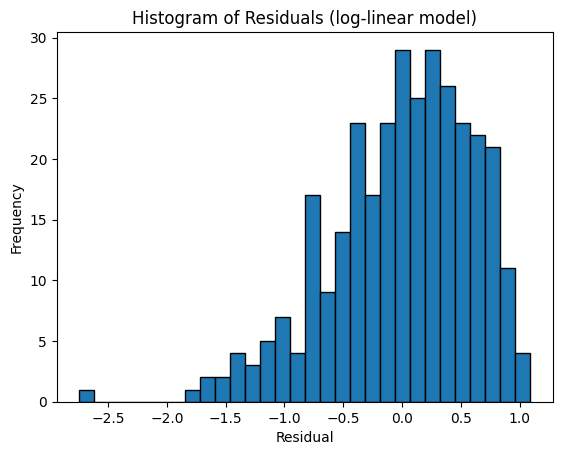

In [68]:
# Plotting histogram of residuals
residuals = model.resid
plt.hist(residuals, bins=30, edgecolor='k')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals (log-linear model)')
plt.show()

#### Regression Coefficients & Covariance Matrix

In [69]:
# Extract regression coefficients and covariance matrix
beta_hat = model.params
cov_matrix = model.cov_params()

# Number of simulations
n_simulations = 1000

# Simulate beta coefficients
simulated_betas = multivariate_normal.rvs(mean=beta_hat, cov=cov_matrix, size=n_simulations)

# Verify coefficients
print("Number of coefficients in beta_hat:", len(beta_hat))
print("Coefficient names:", beta_hat.index.tolist())

Number of coefficients in beta_hat: 15
Coefficient names: ['const', 'League_N', 'Division_W', 'NewLeague_N', 'Years_3', 'Years_4', 'Years_5', 'Years_6', 'Years_other', 'total_performance', 'Salary', 'CAtBat', 'PutOuts', 'Assists', 'Errors']


#### Violin Plot

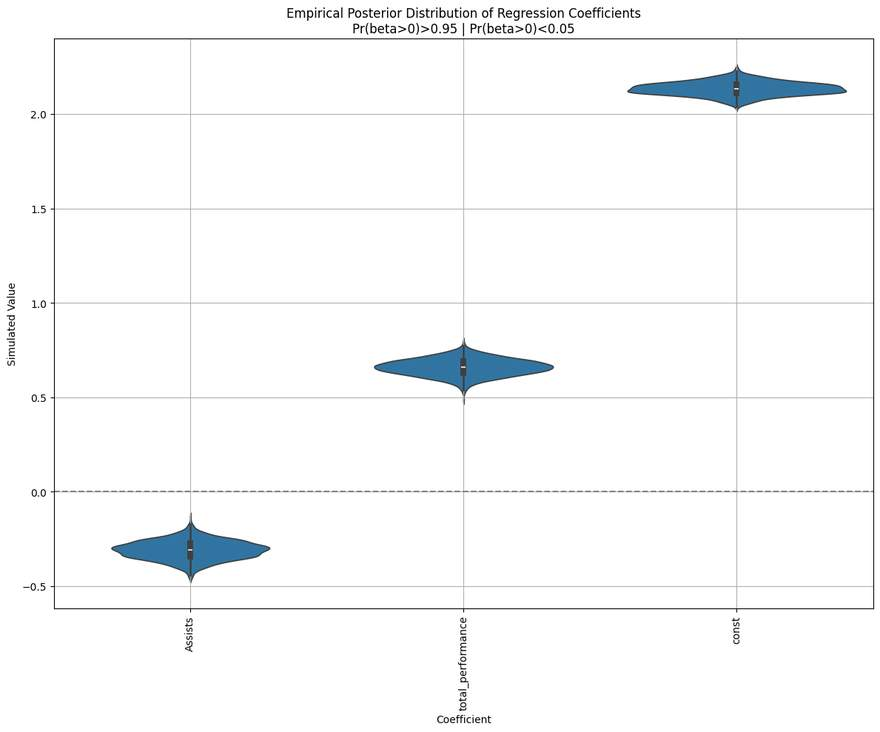

In [70]:
# Draw a Violin Plot
simulations_df = pd.DataFrame(simulated_betas, columns=model.params.index)
long_df = simulations_df.melt(var_name='Coefficient', value_name='Value')
prob_greater_than_zero = long_df.groupby('Coefficient')['Value'].apply(lambda x: np.mean(x > 0)).reset_index()
prob_greater_than_zero.rename(columns={'Value': 'P(coef>0)'}, inplace=True)
filtered_coefs = prob_greater_than_zero[(prob_greater_than_zero['P(coef>0)'] > 0.95) | (prob_greater_than_zero['P(coef>0)'] < 0.05)]['Coefficient']
filtered_long_df = long_df[long_df['Coefficient'].isin(filtered_coefs)]
medians = filtered_long_df.groupby('Coefficient')['Value'].median().reset_index()
medians_sorted = medians.sort_values(by='Value')

plt.figure(figsize=(12, 10))
sns.violinplot(x='Coefficient', y='Value', data=filtered_long_df, order=medians_sorted['Coefficient'])
plt.axhline(y=0, color='grey', linestyle='--')
plt.title('Empirical Posterior Distribution of Regression Coefficients\nPr(beta>0)>0.95 | Pr(beta>0)<0.05')
plt.xticks(rotation=90)
plt.xlabel('Coefficient')
plt.ylabel('Simulated Value')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Posterior Predictive Samples

In [71]:
# Initialize an array to store predictions from each simulation
predicted_counts = np.zeros((n_simulations, X_encoded_with_const.shape[0]))

# Generate predictions for each simulation
# 1. Loop over the number of simulations
# 2. Calculate the predicted rate for each simulation using the simulated coefficients and the data
# 3. Generate the predicted counts by sampling from a normal distribution with the predicted rate and the model scale
# 4. Fill in the i-th position of predicted_counts with the predicted counts
for i in range(n_simulations):
    beta_simulation = simulated_betas[i]
    predicted_log_rate = np.dot(X_encoded_with_const, beta_simulation)
    # Simulate from the posterior-predictive distribution 
    # Uncomment next line
    predicted_counts[i] = np.exp(np.random.normal(predicted_log_rate, np.sqrt(model.scale)))

# Verify shape
print("Shape of predicted_counts:", predicted_counts.shape)

Shape of predicted_counts: (1000, 322)


#### Calculate Metrics

In [72]:
from sklearn.metrics import mean_squared_error

# Calculate metrics
monte_carlo_medians = np.median(predicted_counts, axis=0)
prediction_intervals = np.percentile(predicted_counts, [2.5, 97.5], axis=0)

# Calculate correlation, rmse, bias, and coverage
correlation = np.corrcoef(monte_carlo_medians, y_cleaned)[0, 1]
rmse = np.sqrt(mean_squared_error(y_cleaned, monte_carlo_medians))
bias = np.mean(monte_carlo_medians - y_cleaned)
coverage = np.mean((y_cleaned >= prediction_intervals[0]) & (y_cleaned <= prediction_intervals[1]))

# Verify metrics
print("Monte Carlo Medians Shape:", monte_carlo_medians.shape)
print(f"Correlation: {correlation:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Bias: {bias:.2f}")
print(f"Coverage: {coverage:.2%}")

Monte Carlo Medians Shape: (322,)
Correlation: 0.73
RMSE: 6.16
Bias: -0.16
Coverage: 89.44%


#### Observed vs. Predicted Counts (Log-linear model)

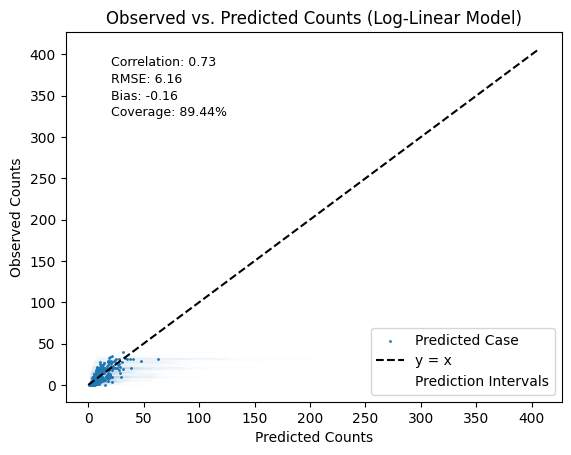

In [73]:
# Find overall min and max for xlim and ylim
predicted_counts_flat = predicted_counts.flatten()
combined_array = np.concatenate([predicted_counts_flat, y_cleaned])

# Calculate min and max
min_val = combined_array.min()
max_val = combined_array.max()

# Plotting
scatter = plt.scatter(monte_carlo_medians, y_cleaned, s=1, alpha=1, label='Predicted Case')
errorbar = plt.errorbar(monte_carlo_medians, y_cleaned, xerr=np.abs(prediction_intervals - monte_carlo_medians), fmt='none', alpha=0.01, label='Prediction Intervals')
y_equals_x = plt.plot([min_val, max_val], [min_val, max_val], 'k--', zorder=3, label='y = x')

# Add legend with metrics
legend_labels = [
    f'Correlation: {correlation:.2f}',
    f'RMSE: {rmse:.2f}',
    f'Bias: {bias:.2f}',
    f'Coverage: {coverage:.2%}'
]

# Add legend for plot elements
plt.legend(loc='lower right')

# Text annotations for metrics
text_x = min_val + (max_val - min_val) * 0.05
text_y_start = max_val - (max_val - min_val) * 0.05
line_height = (max_val - min_val) * 0.05

for i, label in enumerate(legend_labels):
    plt.text(text_x, text_y_start - i * line_height, label, fontsize=9)

plt.title('Observed vs. Predicted Counts (Log-Linear Model)')
plt.xlabel('Predicted Counts')
plt.ylabel('Observed Counts')
plt.show()

### 4) Poisson Regression

#### Fit Poission Regression Model

In [74]:
from statsmodels.api import GLM, Poisson
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

# Fitting the linear regression model
# use function GLM with family=sm.families.Poisson()
model = sm.GLM(y_cleaned, X_encoded_with_const, family=sm.families.Poisson()).fit()

# Displaying the regression results
print(model.summary())

/var/folders/rf/c4wm9pq50j3bjhbyfct63d2h0000gn/T/ipykernel_55113/3440138970.py:2: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  HmRun   No. Observations:                  322
Model:                            GLM   Df Residuals:                      307
Model Family:                 Poisson   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1105.5
Date:                Sun, 23 Mar 2025   Deviance:                       1004.6
Time:                        17:57:44   Pearson chi2:                     907.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9811
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.1969      0.02

#### Regression Coefficients and Covariance Matrix

In [75]:
# Extract regression coefficients and covariance matrix
beta_hat = model.params
cov_matrix = model.cov_params()

# Number of simulations
n_simulations = 1000

# Simulate beta coefficients
simulated_betas = multivariate_normal.rvs(mean=beta_hat, cov=cov_matrix, size=n_simulations)

# Verify coefficients
print("Number of coefficients in beta_hat:", len(beta_hat))
print("Coefficient names:", beta_hat.index.tolist())

Number of coefficients in beta_hat: 15
Coefficient names: ['const', 'League_N', 'Division_W', 'NewLeague_N', 'Years_3', 'Years_4', 'Years_5', 'Years_6', 'Years_other', 'total_performance', 'Salary', 'CAtBat', 'PutOuts', 'Assists', 'Errors']


#### Violin Plot

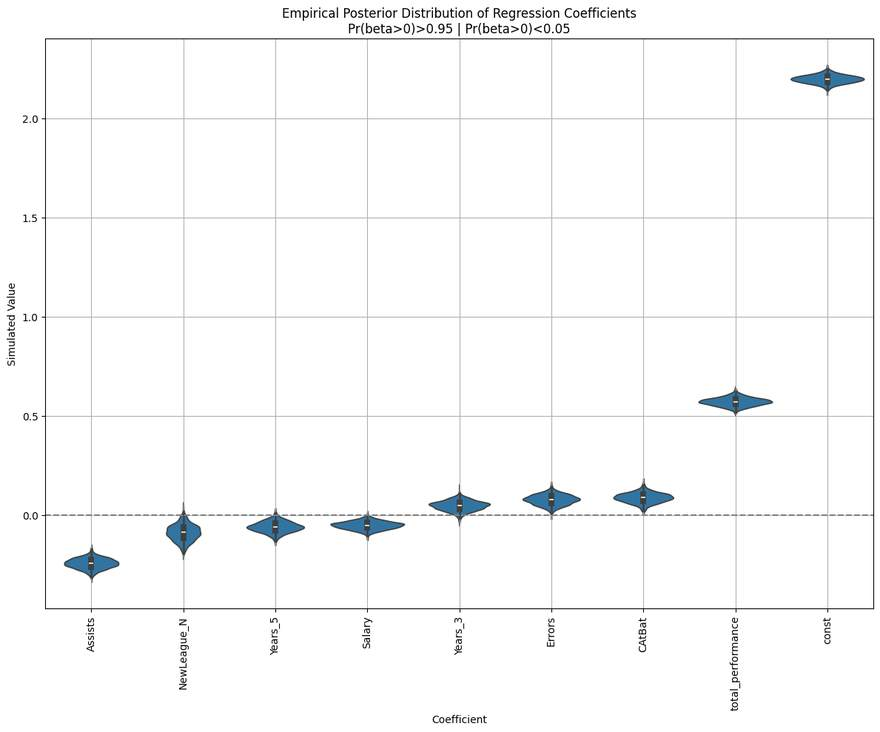

In [76]:
# Transform simulated_betas into a DataFrame for plotting
simulations_df = pd.DataFrame(simulated_betas, columns=model.params.index)

# Convert the DataFrame from wide to long format
long_df = simulations_df.melt(var_name='Coefficient', value_name='Value')

# Calculate the probability of coef > 0 for each coefficient
prob_greater_than_zero = long_df.groupby('Coefficient')['Value'].apply(lambda x: np.mean(x > 0)).reset_index()
prob_greater_than_zero.rename(columns={'Value': 'P(coef>0)'}, inplace=True)

# Filter coefficients based on the probability criterion
filtered_coefs = prob_greater_than_zero[
    (prob_greater_than_zero['P(coef>0)'] > 0.95) | (prob_greater_than_zero['P(coef>0)'] < 0.05)
]['Coefficient']

# Filter the long_df to include only the selected coefficients
filtered_long_df = long_df[long_df['Coefficient'].isin(filtered_coefs)]

# Calculate the median of the simulated values for each filtered coefficient
medians = filtered_long_df.groupby('Coefficient')['Value'].median().reset_index()

# Sort the filtered medians
medians_sorted = medians.sort_values(by='Value')

# Plotting the filtered and ordered coefficients
plt.figure(figsize=(12, 10))  # Adjust the figure size as needed
sns.violinplot(x='Coefficient', y='Value', data=filtered_long_df, order=medians_sorted['Coefficient'])

# Add a vertical dotted line at x = 0
plt.axhline(y=0, color='grey', linestyle='--')

# Additional customization
plt.title('Empirical Posterior Distribution of Regression Coefficients\nPr(beta>0)>0.95 | Pr(beta>0)<0.05')
plt.xticks(rotation=90)  # Rotate the x-axis labels for better readability
plt.xlabel('Coefficient')
plt.ylabel('Simulated Value')
plt.grid(True)

# Display the plot
plt.tight_layout()  # Adjust layout to not cut off labels
plt.show()

#### Initialize Array for Prediction

In [77]:
# Initialize an array to store predictions from each simulation
predicted_counts = np.zeros((n_simulations, X_encoded_with_const.shape[0]))

# Verify initialization
print("Shape of predicted_counts:", predicted_counts.shape)

Shape of predicted_counts: (1000, 322)


#### Predictive Samples

In [78]:
# Generate predictions for each simulation
for i in range(n_simulations):
    beta_simulation = simulated_betas[i]
    predicted_rate = np.exp(np.dot(X_encoded_with_const, beta_simulation))
    predicted_counts[i] = np.random.poisson(predicted_rate)

#### Calculate Metrics

In [79]:
from sklearn.metrics import mean_squared_error

# Calculate metrics
monte_carlo_medians = np.median(predicted_counts, axis=0)
prediction_intervals = np.percentile(predicted_counts, [2.5, 97.5], axis=0)

correlation = np.corrcoef(monte_carlo_medians, y_cleaned)[0, 1]
rmse = np.sqrt(mean_squared_error(y_cleaned, monte_carlo_medians))
bias = np.mean(monte_carlo_medians - y_cleaned)
coverage = np.mean((y_cleaned >= prediction_intervals[0]) & (y_cleaned <= prediction_intervals[1]))

# Verify metrics
print("Monte Carlo Medians Shape:", monte_carlo_medians.shape)
print(f"Correlation: {correlation:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Bias: {bias:.2f}")
print(f"Coverage: {coverage:.2%}")

Monte Carlo Medians Shape: (322,)
Correlation: 0.75
RMSE: 5.78
Bias: -0.19
Coverage: 78.57%


#### Prediction vs. Observation (Poisson)

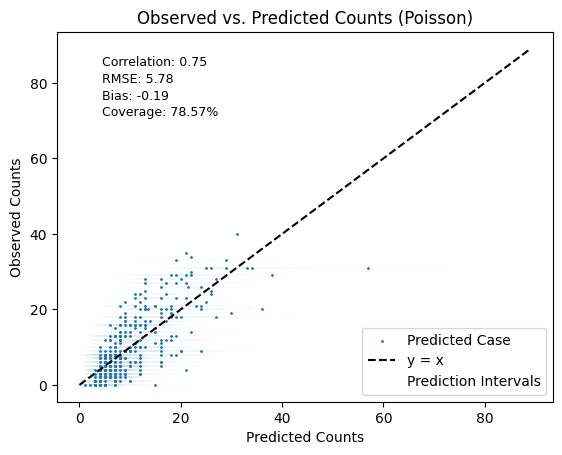

In [80]:
# Plot Predictions v. Observations

predicted_counts_flat = predicted_counts.flatten()
combined_array = np.concatenate([predicted_counts_flat, y_cleaned])
min_val = combined_array.min()
max_val = combined_array.max()

plt.scatter(monte_carlo_medians, y_cleaned, s=1, alpha=1, label='Predicted Case')
plt.errorbar(monte_carlo_medians, y_cleaned, xerr=np.abs(prediction_intervals - monte_carlo_medians), fmt='none', alpha=0.01, label='Prediction Intervals')
plt.plot([min_val, max_val], [min_val, max_val], 'k--', zorder=3, label='y = x')

legend_labels = [
    f'Correlation: {correlation:.2f}',
    f'RMSE: {rmse:.2f}',
    f'Bias: {bias:.2f}',
    f'Coverage: {coverage:.2%}'
]

plt.legend(loc='lower right')
text_x = min_val + (max_val - min_val) * 0.05
text_y_start = max_val - (max_val - min_val) * 0.05
line_height = (max_val - min_val) * 0.05

for i, label in enumerate(legend_labels):
    plt.text(text_x, text_y_start - i * line_height, label, fontsize=9)

plt.title('Observed vs. Predicted Counts (Poisson)')
plt.xlabel('Predicted Counts')
plt.ylabel('Observed Counts')
plt.show()

## Commentary on Model Comparison:

For predicting the number of home runs (HmRun), which is count data, the Poisson regression model is likely the most useful of the three models (linear, log-linear, and Poisson).

1. The Poisson model is specifically designed for count data, assuming non-negative integers and a distribution where the mean equals the variance. Home run counts naturally fit this framework, whereas the linear model can predict negative values and the log-linear model, while better, relies on a normal approximation after transformation.

2.In terms of Fit and residuals, the Poisson model's summary should show a lower deviance or better fit if the data follows a Poisson process. The linear model's residuals were likely non-normal (due to count constraints), and the log-linear model's residuals improved but still approximated normality. The Poisson model directly models the count process, potentially reducing bias.

3. Prediction Accuracy
- The Poisson model's coverage (proportion of observed counts within 95% intervals) should be closer to 95% compared to the others, indicating better uncertainty quantification. The RMSE and correlation from the Poisson model should also reflect a tighter fit to the observed counts, especially if overdispersion is minimal.

4. Interpretation
- Coefficients in the Poisson model are on the log-rate scale, directly interpretable as rate ratios (e.g., a 1-unit increase in a predictor multiplies the expected count by exp(coef)), which is intuitive for baseball statistics like total_performance or CAtBat.

However, if the data exhibits overdispersion (variance > mean), a negative binomial model might be better, but among these three, Poisson is optimal given its theoretical alignment with count data like home runs. The linear model is least suitable due to its inability to handle count constraints, and the log-linear model is a middle ground but less direct than Poisson.